In [19]:
import cv2
import matplotlib.pyplot as plt
import glob
import numpy as np

images = []

for filename in filenames:
    # IMREAD_UNCHANGED loads the 4th channel (Alpha) if it exists
    img = cv2.imread(filename, cv2.IMREAD_UNCHANGED)

    if img is None:
        print(f"Couldn't load {filename}")
        continue

    # 1. Extract Color/Grayscale and Alpha Channel
    if img.ndim == 3 and img.shape[2] == 4:  # Image has BGRA (4 channels)
        bgr = img[:, :, :3]
        alpha = img[:, :, 3]

        # Convert RGB to Grayscale
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

        # 2. Convert erased/transparent pixels (Alpha == 0) to NaN
        gray[alpha == 0] = np.nan

    elif img.ndim == 3 and img.shape[2] == 3:  # Image has no alpha (3 channels)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    else:  # Standard 1-channel grayscale image
        gray = img.astype(np.float32)

    images.append(gray)

images = np.array(images)

/tmp/ipykernel_533/2961423123.py:1: RuntimeWarning: invalid value encountered in cast
  background = np.median(images, axis=0).astype(np.uint8)


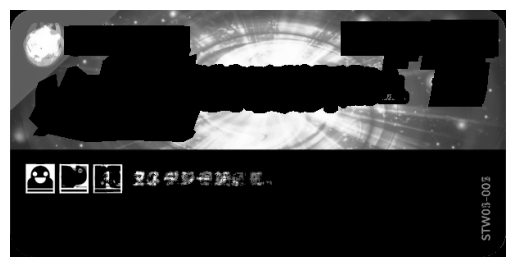

In [20]:
background = np.median(images, axis=0).astype(np.uint8)


plt.imshow(background, cmap="gray")
plt.axis("off")
plt.show()

/tmp/ipykernel_533/2510620168.py:1: RuntimeWarning: All-NaN slice encountered
  backgroundnan = np.nanmedian(images, axis=0).astype(np.uint8)
/tmp/ipykernel_533/2510620168.py:1: RuntimeWarning: invalid value encountered in cast
  backgroundnan = np.nanmedian(images, axis=0).astype(np.uint8)


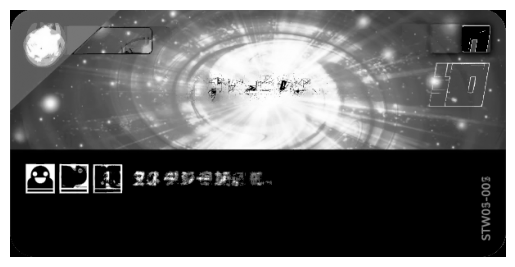

In [21]:
backgroundnan = np.nanmedian(images, axis=0).astype(np.uint8)


plt.imshow(backgroundnan, cmap="gray")
plt.axis("off")
plt.show()

/tmp/ipykernel_533/2993875441.py:43: RuntimeWarning: All-NaN slice encountered
  background_float = np.nanmedian(images_array, axis=0)


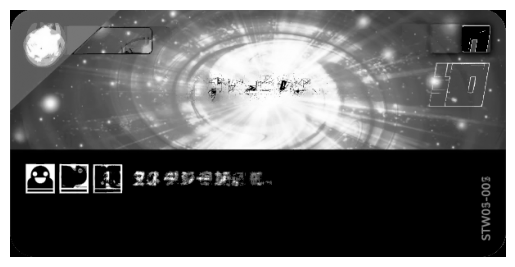

In [ ]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np

filenames = glob.glob("plakoro/**/*.webp")
if not filenames:
    raise FileNotFoundError("No webp files found in target directory.")

processed_stack = []

for filename in filenames:
    # IMREAD_UNCHANGED loads the 4th channel (Alpha) if it exists
    img = cv2.imread(filename, cv2.IMREAD_UNCHANGED)

    if img is None:
        print(f"Couldn't load {filename}")
        continue

    # 1. Extract Color/Grayscale and Alpha Channel
    if img.ndim == 3 and img.shape[2] == 4:  # Image has BGRA (4 channels)
        bgr = img[:, :, :3]
        alpha = img[:, :, 3]

        # Convert RGB to Grayscale
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

        # 2. Convert erased/transparent pixels (Alpha == 0) to NaN
        gray[alpha == 0] = np.nan

    elif img.ndim == 3 and img.shape[2] == 3:  # Image has no alpha (3 channels)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    else:  # Standard 1-channel grayscale image
        gray = img.astype(np.float32)

    processed_stack.append(gray)

# 3. Stack images and calculate median, completely ignoring NaN (transparent) pixels
images_array = np.array(processed_stack)

# np.nanmedian ignores NaN values per pixel coordinate
background_float = np.nanmedian(images_array, axis=0)

# Convert back to uint8 image format, converting any leftover unmasked NaNs to 0
background = np.nan_to_num(background_float, nan=0).astype(np.uint8)

# 4. Display result
plt.imshow(background, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np


def expand_deleted_zone(alpha_channel, expand_pixels=2):
    """Takes an alpha channel, identifies deleted/transparent regions (alpha < 250),

    and expands that deleted zone outward by `expand_pixels`.
    """
    # 1. Create a binary mask where 255 = deleted/transparent region
    # Using 250 instead of 0 to capture semi-transparent soft edges from GIMP
    deleted_mask = (alpha_channel < 250).astype(np.uint8) * 255

    # 2. Define a structuring element (kernel) based on the expansion radius
    kernel_size = expand_pixels * 2 + 1  # 2 pixels radius -> 5x5 kernel
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)
    )

    # 3. Dilate the mask to push the "deleted" boundaries outward by `expand_pixels`
    expanded_deleted_mask = cv2.dilate(deleted_mask, kernel, iterations=1)

    # Return boolean array where True = pixels to turn into NaN
    return expanded_deleted_mask > 0


# Load filenames
filenames = glob.glob("plakoro/**/*.webp")
if not filenames:
    raise FileNotFoundError("No webp files found.")

processed_stack = []

for filename in filenames:
    # Read image including the Alpha channel
    img = cv2.imread(filename, cv2.IMREAD_UNCHANGED)

    if img is None:
        print(f"Couldn't load {filename}")
        continue

    # Process 4-channel BGRA images
    if img.ndim == 3 and img.shape[2] == 4:
        bgr = img[:, :, :3]
        alpha = img[:, :, 3]

        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

        # Expand the NaN zone by 2 pixels
        nan_mask = expand_deleted_zone(alpha, expand_pixels=2)

        # Apply NaN to the expanded region
        gray[nan_mask] = np.nan

    elif img.ndim == 3 and img.shape[2] == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        gray = img.astype(np.float32)

    processed_stack.append(gray)

# Compute median ignoring NaN values
images_array = np.array(processed_stack)
background_float = np.nanmedian(images_array, axis=0)

# Convert back to image format
background = np.nan_to_num(background_float, nan=0).astype(np.uint8)

plt.imshow(background, cmap="gray")
plt.axis("off")
plt.show()

cv2.imwrite("background_2px.png", background)

: 